In [1]:
import jax

# jax.config.update("jax_enable_x64", False)
jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "cpu")
jax.config.update("jax_platform_name", "gpu")
# jax.config.update("jax_debug_nans", True)
print(jax.local_devices()[0].device_kind)
from jax import numpy as np, random as jr, tree as jtu
import os


import zodiax as zdx
from zodiax.optimisation import sgd, adam
import dLux.utils as dlu

from amigo.fitting import Trainer
import dorito


# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

NVIDIA GeForce RTX 2080 Ti


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    morgana = "/media/morgana1/"
else:
    morgana = "/Volumes/morgana1/"

amigo_cache = os.path.join(morgana, "snert/max/data/amigo_files/")

cache = os.path.join(amigo_cache, "v_0.0.10/")
output_path = os.path.join(amigo_cache, "outputs/easy_binary/")

load_dict = lambda x: np.load(x, allow_pickle=True).item()
cal_vis_outputs = load_dict(os.path.join(output_path, "cal_vis.npy"))

print(cal_vis_outputs.keys())

dict_keys(['F380M', 'F430M', 'F480M'])


In [3]:
from amigo.model_fits import ModelFit
from amigo.vis_models import vis_to_im, fft_coords
from amigo.vis_analysis import AmigoOIData
from amigo.misc import interp
from jax import Array, numpy as np
import dLux.utils as dlu


def local_average(image, i, j, exclude_center=True):
    h, w = image.shape
    # Get the 3×3 neighborhood bounds
    i_min = max(i - 1, 0)
    i_max = min(i + 2, h)
    j_min = max(j - 1, 0)
    j_max = min(j + 2, w)

    patch = image[i_min:i_max, j_min:j_max]

    if exclude_center:
        patch = patch.copy()
        patch = patch.at[i - i_min, j - j_min].set(0.0)
        return patch.sum() / (patch.size - 1)
    else:
        return patch.mean()


class UniqueOIFit(dorito.model_fits.ResolvedOIFit):

    def to_cvis(self, model, distribution):

        # Perform MFT and move to OTF plane
        uv = self.to_otf(model, distribution)  # shape (102, 102)

        # Normalise the complex u,v plane
        uv /= model.params["base_uv"][self.get_key("base_uv")]

        # Downsample to the desired u,v resolution
        uv = dlu.downsample(uv, 2, mean=True)  # shape (51, 51)

        # flatten and take first half (u,v symmetry)
        cvis = uv.flatten()[: uv.size // 2]

        return cvis

    def model_disco(self, model, distribution):
        """
        Compute the model visibilities and phases for the given model object.
        """
        cvis = self.to_cvis(model, distribution)
        return self.flatten_model(cvis)

    def dirty_image(self, model, npix=None, rotate=True, pad_factor: int = 10):
        """
        Get the dirty image via MFT. This is the image that would be obtained
        if the visibilities were directly transformed back to the image plane.

        Args:
            model: The model object containing the parameters.
            npix: The number of pixels in one axis of the dirty image.
                    If None, uses the same size as the model source distribution.
            rotate: If True, rotates the dirty image by the parallactic angle.
                    If a float, rotates by that (-'ve) angle in radians.
        Returns:
            Array: The dirty image, normalised to sum to 1.
        """

        # if npix is None:
        #     npix = model.get_distribution(self).shape[0]

        # converting to u,v visibilities
        log_vis = np.dot(np.linalg.pinv(self.vis_mat), self.vis)
        phase = np.dot(np.linalg.pinv(self.phi_mat), self.phi)

        # Make an image
        amp_im, phi_im = vis_to_im(log_vis, phase, (51, 51))

        # Create the dirty image
        pix_cvis = np.exp(amp_im + 1j * phi_im)
        # pix_cvis = np.pad(
        #     pix_cvis,
        #     pad_factor * 51,
        #     mode="constant",
        #     constant_values=1 + 0j,
        # )
        dirty_image = np.fft.fftshift(np.fft.ifft2(pix_cvis))

        # # Taking amplitudes
        dirty_image = np.abs(dirty_image)

        # # Nuke the bright middle pixel
        # c = dirty_image.shape[0] // 2
        # dirty_image = dirty_image.at[c, c].set(local_average(dirty_image, c, c))

        # # Coordinates
        # pscale = 2 * 6.603464 / npix * model.oversample
        # coords = dlu.rad2arcsec(fft_coords(self.wavel, 51, pscale, pad_factor))
        # extent = (coords.min(), coords.max(), coords.min(), coords.max())

        # # Downsampling
        # knot_coords = dlu.pixel_coords(npixels=dirty_image.shape[0], diameter=1.0)
        # sample_coords = dlu.pixel_coords(npixels=npix, diameter=1 / model.oversample)
        # dirty_image = interp(dirty_image, knot_coords, sample_coords, method="cubic")

        # Optional rotation of the dirty image
        if rotate:
            dirty_image = self.rotate(dirty_image)

        # # plot
        # plt.figure(figsize=(5, 3))
        # plt.imshow(dirty_image / dirty_image.sum(), extent=extent)
        # plt.colorbar()
        # plt.xlabel("arcsec")
        # plt.ylabel("arcsec")
        # plt.title("Dirty image from DISCOs")
        # plt.tight_layout()
        # plt.show()

        # Normalise the image
        return dirty_image / dirty_image.sum()

    def __call__(self, model, rotate=True):
        """
        Simulate the DISCOs from the resolved source distribution.
        This method retrieves the distribution from the model, optionally rotates it,
        and then computes the DISCOs using the model_disco method.
        Args:
            model: The model object containing the parameters.
            rotate: If True, rotates the distribution by the parallactic angle.
                    If a float, rotates by that (-'ve) angle in radians.
        Returns:
            tuple: A tuple containing the amplitudes and phases in the DISCO basis.
        """
        # NOTE: Distribution must be odd number of pixels in one axis
        distribution = model.get_distribution(self)

        if rotate:
            distribution = self.rotate(distribution)

        return self.model_disco(model, distribution)

In [14]:
optics_diameter = 6.603464  # JWST aperture diameter in meters
otf_coords = dlu.pixel_coords(51, 2 * optics_diameter)

ois = [
    UniqueOIFit(oi_data, key, filter=key[:5])
    for key, oi_data in cal_vis_outputs.items()
]
for oi in ois:
    print(oi.key)

# ois = ois[2:]
ois = [ois[-1]]

# distribution = np.zeros((41, 41)).at[20, 20].set(1.0)  # + 1e-16
# distribution = np.ones((51, 51))
distribution = np.ones((51, 51))
# distribution = np.zeros((51, 51)).at[25, 25].set(1.0) + 1e-2

model = dorito.models.ResolvedDiscoModel(
    ois,
    distribution,
    uv_npixels=2 * otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(otf_coords[0, 0]).mean(),
    oversample=1.0,
)


# Initialise at the mean dirty image
params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
hypot = lambda x: np.sqrt(np.array([_x**2 for _x in x]).sum(0))
for filt in ["F380M", "F480M"]:
    dirty_imgs = [
        oi.dirty_image(model, rotate=False) for oi in ois if oi.filter == filt
    ]

    if dirty_imgs == []:
        print(f"No dirty images for filter {filt}, skipping initialisation.")
        continue
    mean_dirty = hypot(dirty_imgs)
    init_dist = np.log10(mean_dirty / mean_dirty.sum() + 1e-8)
    for oi in ois:
        if oi.filter == filt:
            params["log_dist"][oi.get_key("log_dist")] = init_dist

model = model.set("params", params)

F380M
F430M
F480M
No dirty images for filter F380M, skipping initialisation.


In [15]:
import jax.scipy as jsp
import jax.random as jr


def difflim_to_cov(model, exposure, factor):

    # calculating lambda over D
    D = 6.603464  # m
    lambda_on_D = dlu.rad2arcsec(exposure.wavel / D)

    # calculating sigma, with some factor in front of lambda on D
    sigma = dorito.misc.fwhm_to_sigma(factor * lambda_on_D)

    # return covariance matrix
    return [[sigma**2, 0], [0, sigma**2]]


def blur_distribution(array, model, exposure, extent=0.25, factor=1.0):
    cov = difflim_to_cov(model, exposure, factor)

    x = np.arange(-extent, extent, dlu.rad2arcsec(model.pscale_in))
    X, Y = np.meshgrid(x, x)
    pos = np.dstack((X, Y))

    kernel = jsp.stats.multivariate_normal.pdf(jr.PRNGKey(0), pos, np.array(cov))

    distribution = jsp.signal.convolve2d(
        array,
        kernel,
        mode="same",
        # method="fft",
    )
    return distribution / distribution.sum()


# def normalise_distribution(model_params, args):
#     params = model_params.params
#     if "log_dist" in params.keys():
#         for k, log_dist in params["log_dist"].items():
#             distribution = 10**log_dist
#             params["log_dist"][k] = np.log10(distribution / distribution.sum())

#     return model_params.set("params", params), args


def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist

            # centre = distribution.shape[0] // 2
            # norm = distribution[centre, centre]

            norm = distribution.sum()

            params["log_dist"][k] = np.log10(distribution / norm)

    return model_params.set("params", params), args


# def grad_fn(model, grads, args):

#     threshold = 1e-5

#     params = grads.params
#     if "log_dist" in params.keys():
#         for k, grad in params["log_dist"].items():
#             grad = np.clip(grad, threshold, threshold)
#             params["log_dist"][k] = grad

#     return grads.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.6e}")


def log_likelihood(model, oi, args={}):
    data = np.concatenate([oi.vis, oi.phi])
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = oi(model)  # same shape as data

    residual = data - model_vis
    nll = np.sum(0.5 * (residual / err) ** 2 + np.log(err * np.sqrt(2 * np.pi)))

    return nll


def apply_regularisers(model, exposure, args):
    # creating a list of regularisation functions and regularisation hyperparameters
    fn_list = [args["reg_func_dict"][reg] for reg in args["reg_dict"].keys()]
    coeff_list = list(args["reg_dict"].values())

    # evaluating the regularisation term with each for each regulariser
    priors = [
        coeff * fn(model, exposure, args) for coeff, fn in zip(coeff_list, fn_list)
    ]
    prior = np.array(priors).sum()  # summing the different regularisers

    return prior


def calc_loglike_prior(model, exposure, args):
    # this is per exposure

    # regular likelihood term
    likelihood = np.nanmean(log_likelihood(model, exposure))

    # grabbing and exponentiating log distributions
    prior = apply_regularisers(model, exposure, args)

    return likelihood, prior


def regularised_loss_fn(model, exposure, args={"reg_func_dict": {}, "reg_dict": {}}):
    # this is per exposure
    likelihood, prior = calc_loglike_prior(model, exposure, args)
    return likelihood + prior, ()
    # return likelihood + prior


def phase_centre(model, oi, args={}):

    distribution = model.get_distribution(oi)

    # Tip/Tilt vectors (ramp in u,v)
    mu = oi.u / np.linalg.norm(oi.u)
    mv = oi.v / np.linalg.norm(oi.v)

    # to log visibilities
    _log_amp, phase = oi.to_logvis(model, distribution)

    # calculating the phase centre of the distribution
    return np.hypot(np.dot(mu, phase), np.dot(mv, phase))


def centered_loss_fn(model, exposure, args, width=1e-3):
    likelihood, prior = calc_loglike_prior(model, exposure, args)

    # phase centre prior
    centre = phase_centre(model, exposure, args)
    prior += -jax.scipy.stats.norm.logpdf(centre, loc=0.0, scale=width)

    return likelihood + prior, ()


import optax
from zodiax.optimisation import scheduler


def adamw(lr: float, start: int, *schedule):
    return optax.adamw(scheduler(lr, start, *schedule))

In [16]:
for oi in ois:
    print(centered_loss_fn(model, oi, {"reg_func_dict": {}, "reg_dict": {}}))

(Array(8389.32414253, dtype=float64), ())


In [27]:
jax.config.update("jax_debug_nans", True)

n_epoch = 5_000

config = {
    "log_dist": adam(1e-3, 0),
    # "log_dist": adam(1e-1, 0),
    # "log_dist": adam(2e-2, 0, (100, 0.1), (2000, 0.1)),
    # "log_dist": adamw(1e-2, 0, (400, 0.02)),
    # "log_dist": sgd(1e-8, 0, (1000, 0.1)),
    # "log_dist": sgd(1e-3, 0),
    # "log_dist": optax.sgd(1e-8, 0),
    # "log_dist": sgd(1e-8, 0)  # (100, 10), (2000, 0.5)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
    },
    "reg_dict": {
        "ME": 1e2,
        # "ME": 1e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 5e6,
    },
}

trainer = Trainer(
    # trainer = Trainer(
    # loss_fn=regularised_loss_fn,
    loss_fn=centered_loss_fn,
    # cache=fisher_cache,
    # grad_fn=grad_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
    # batches=exposures,
)

0it [00:00, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 8,117.04
Estimated run time: 0:00:44
Full Time: 0:00:57
Final Loss: -376.29


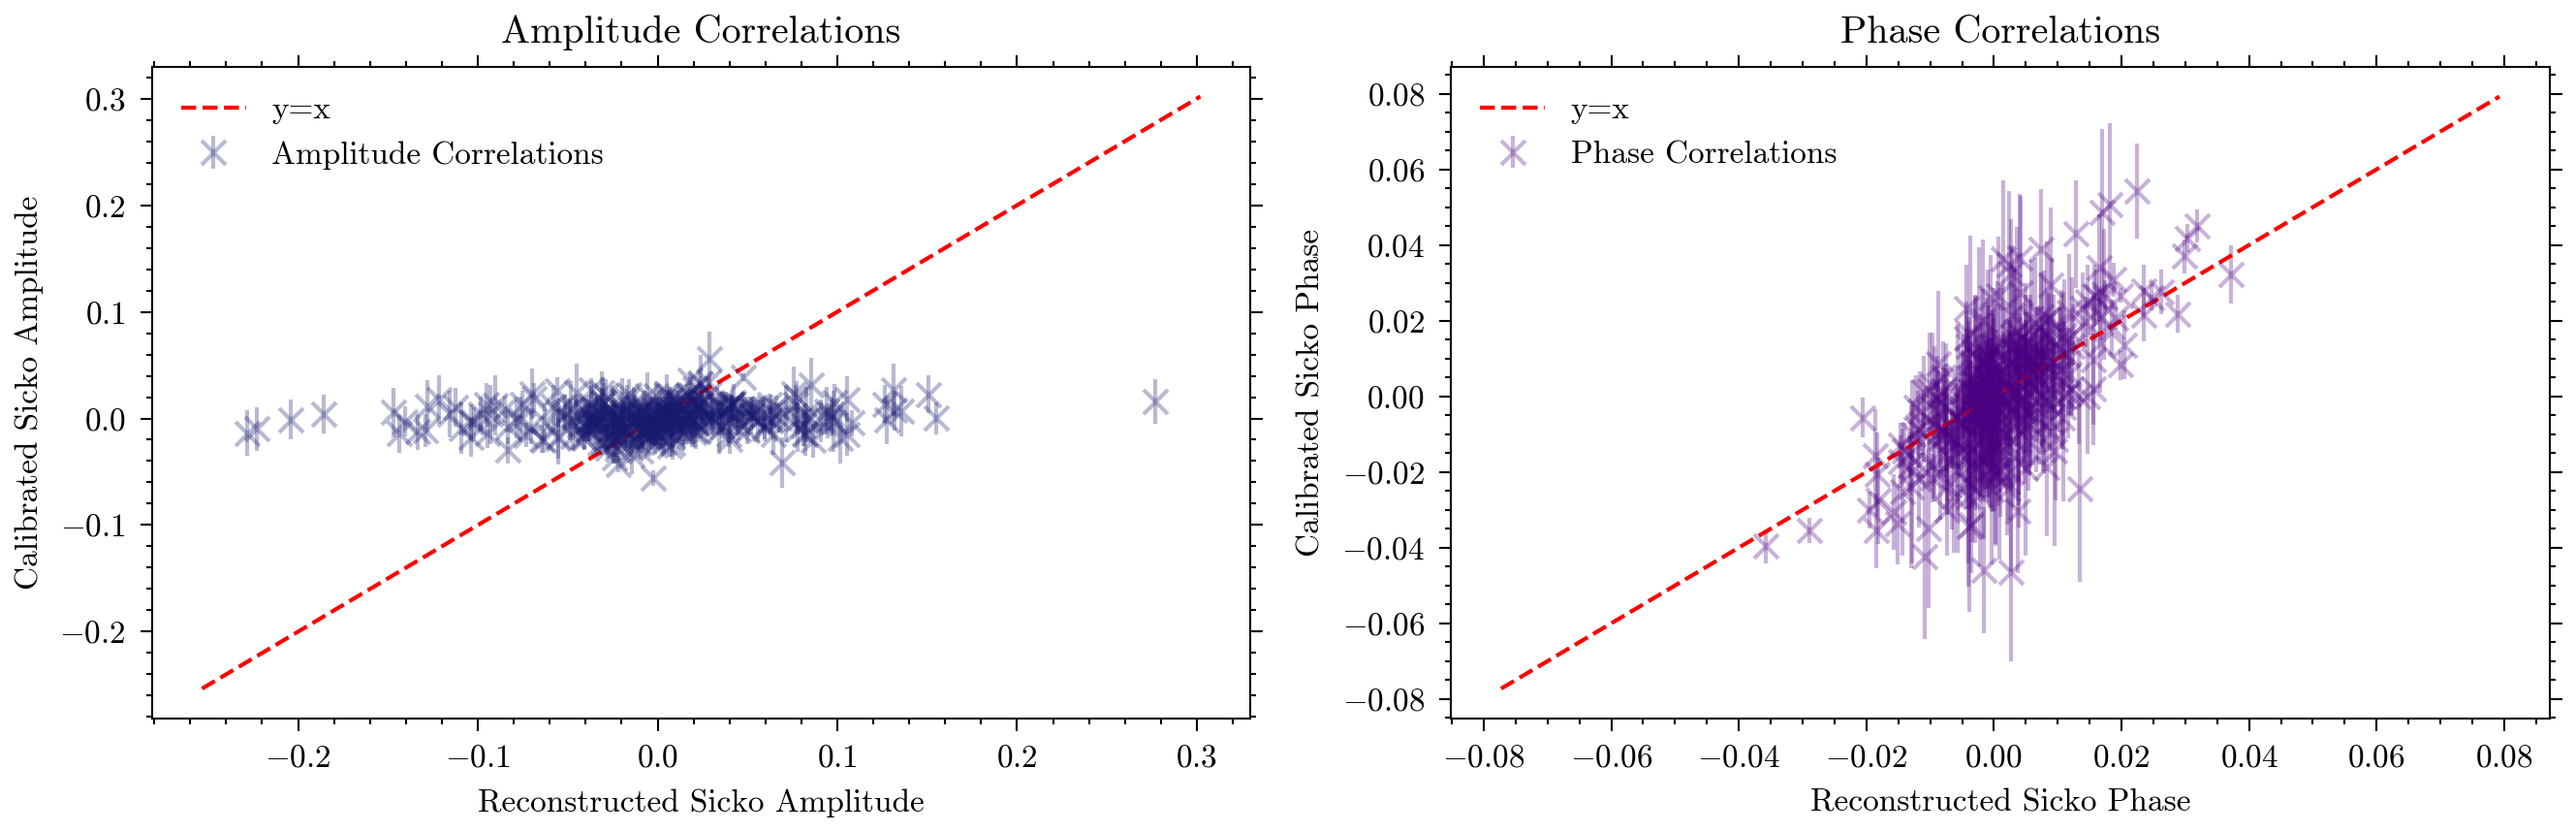

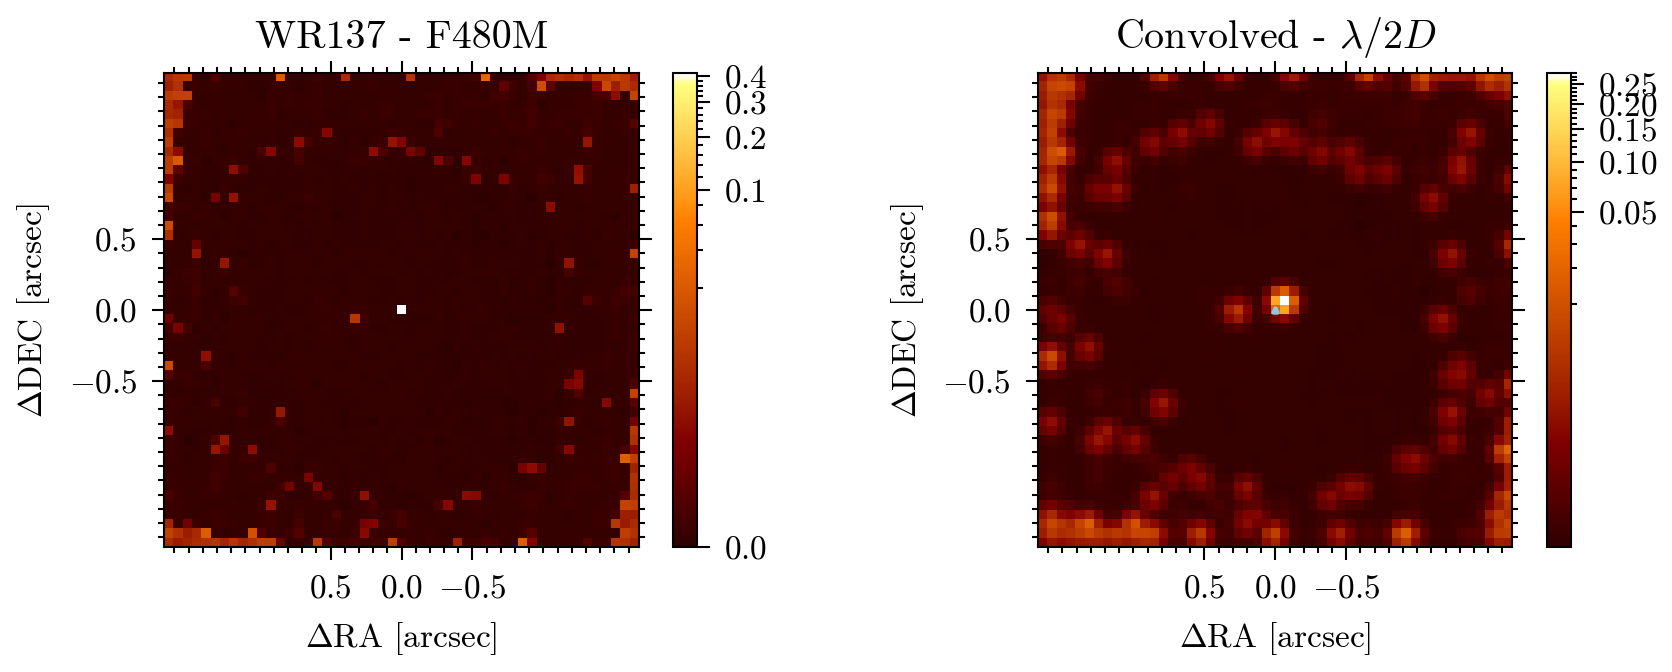

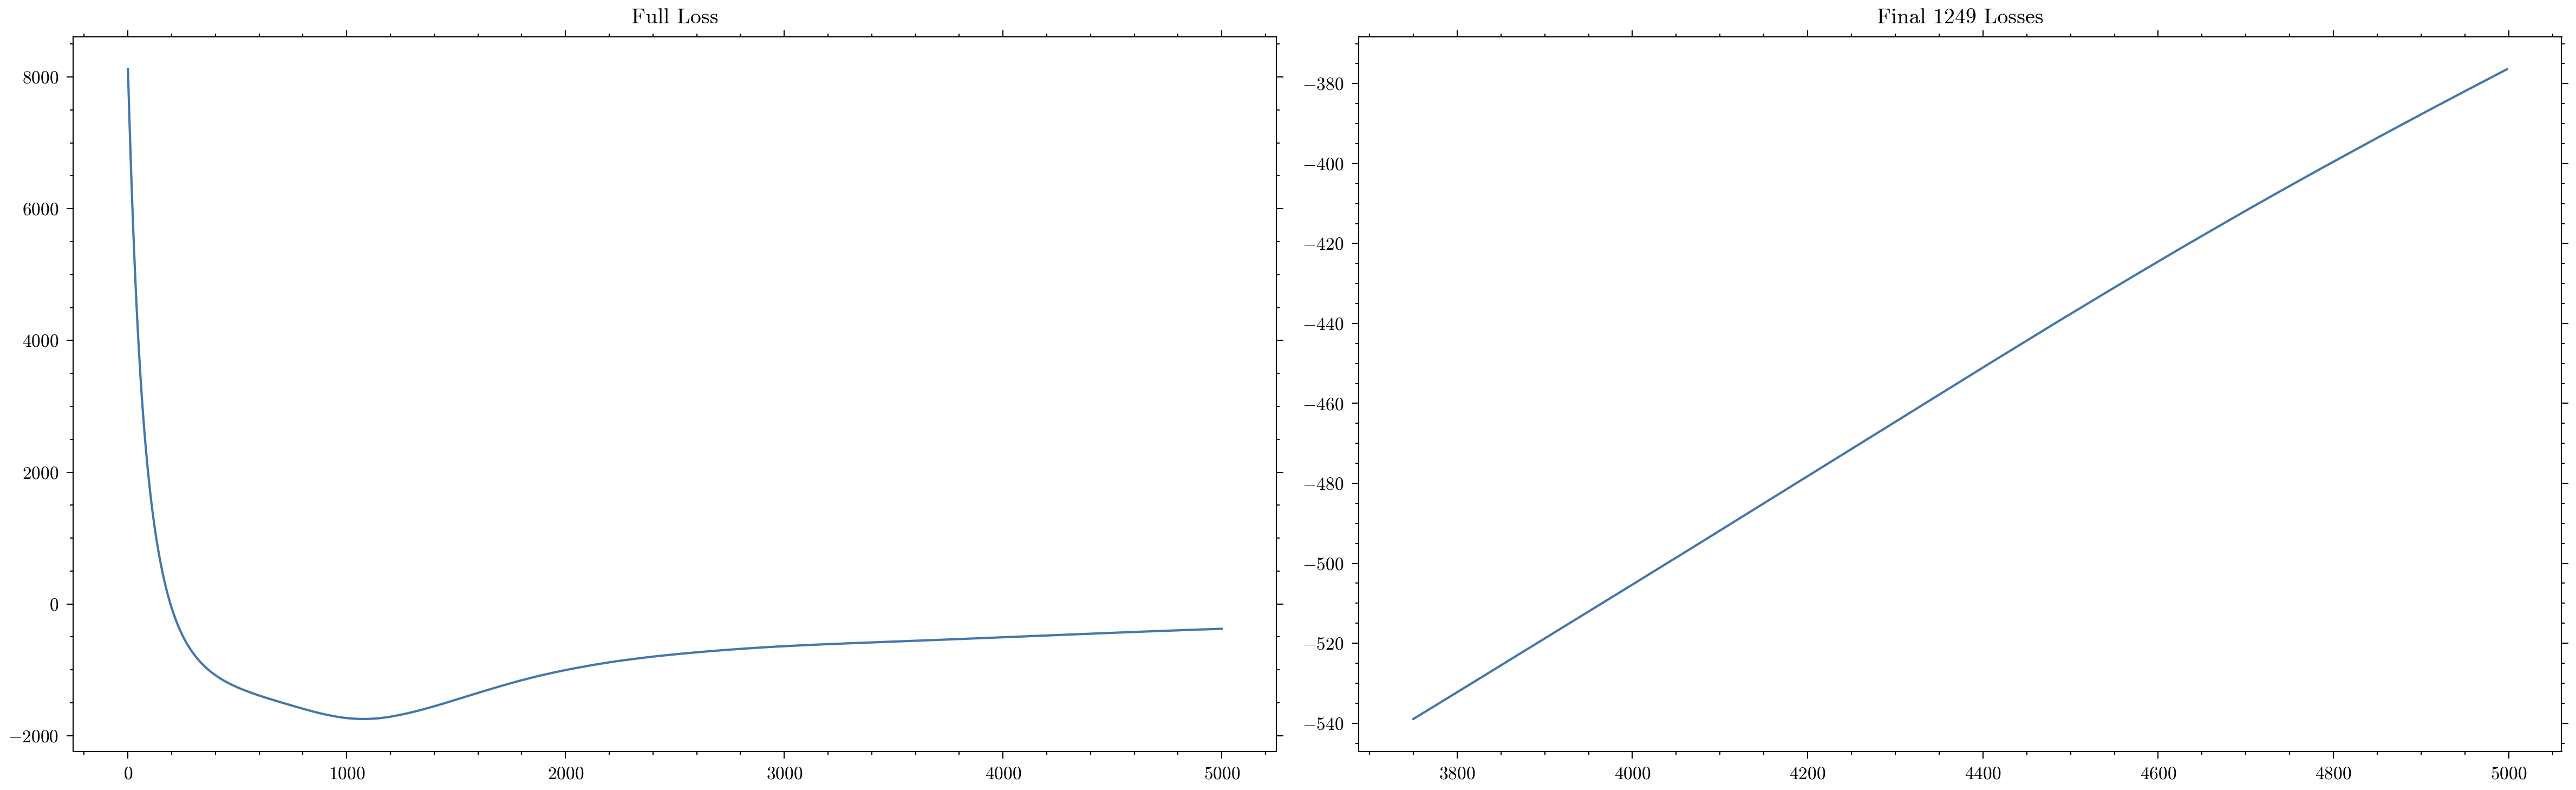

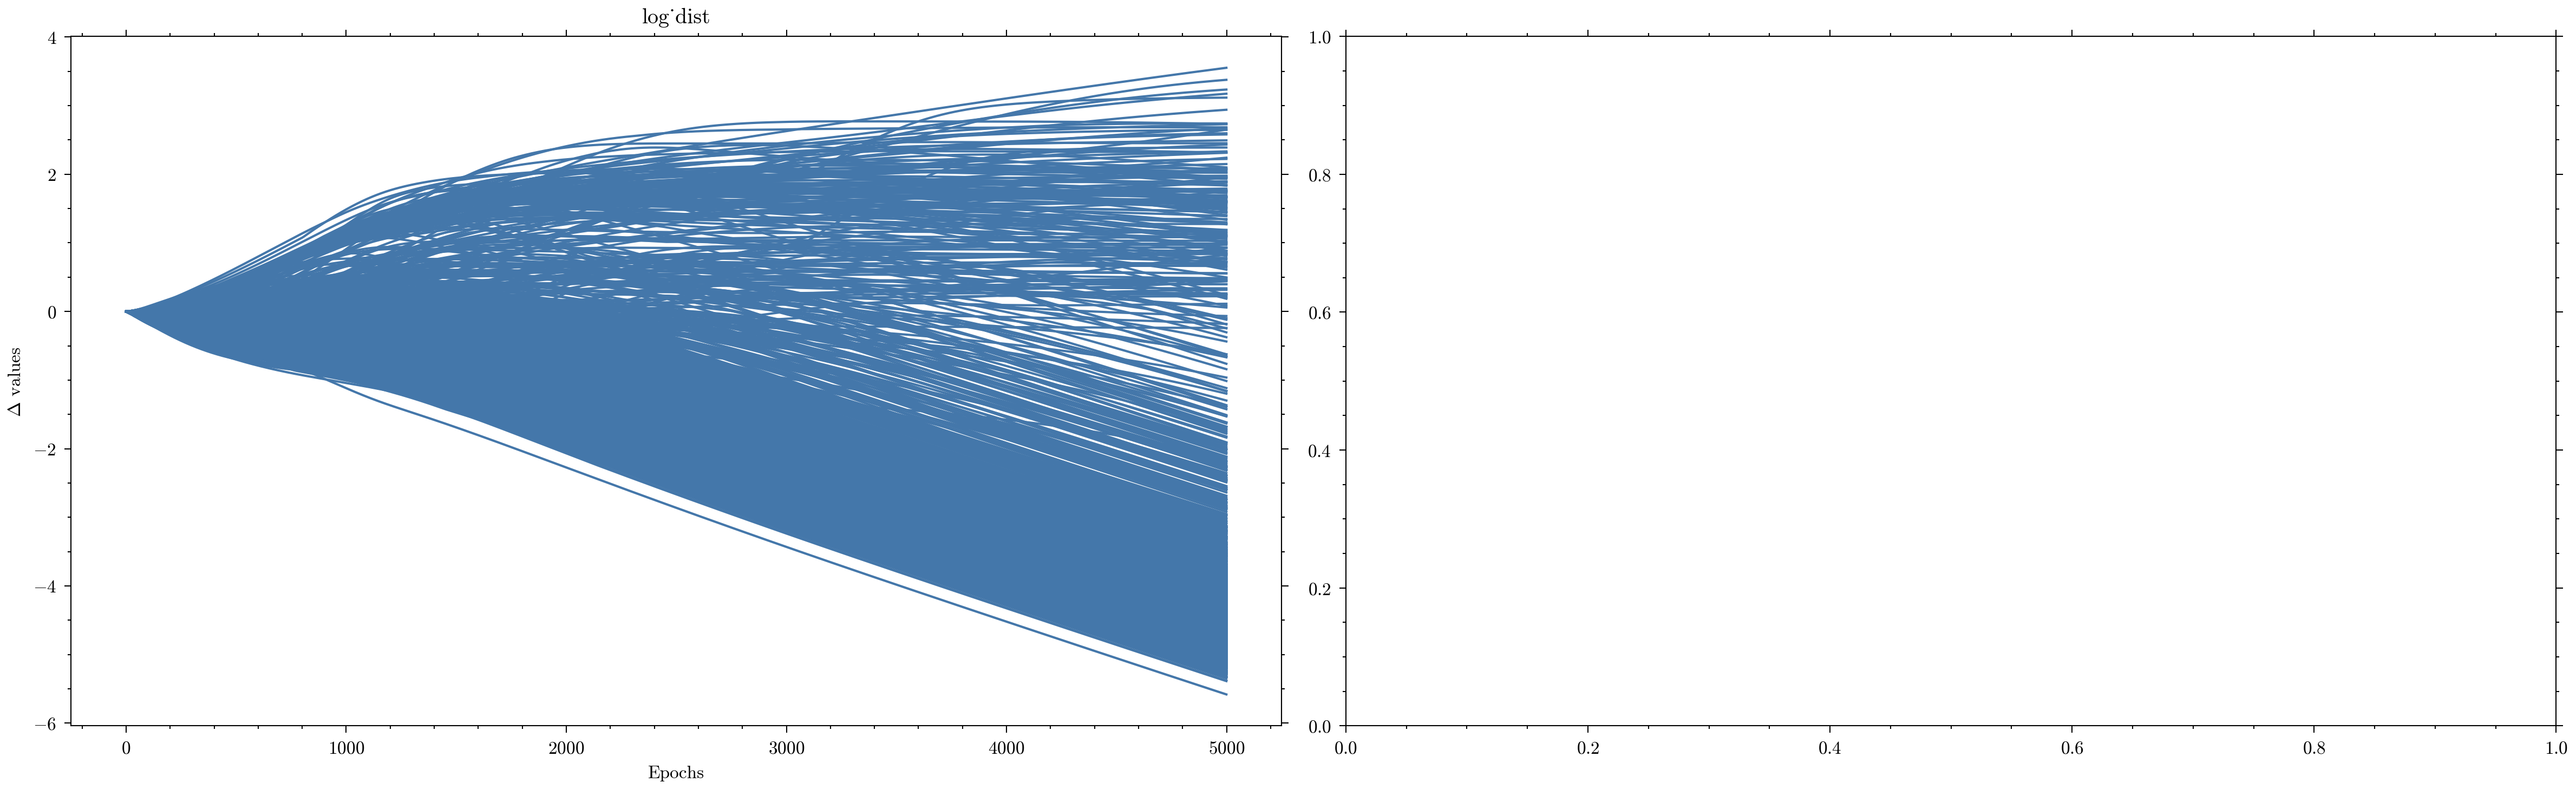

In [28]:
from amigo import plotting

for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    disco_amp, disco_phase = np.split(oi(result.model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.5, -0.25, 0, 0.25, 0.5]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.2,
        vmin=0,
    )
    # ax[0].scatter([0], [0], marker="^", color="skyblue", s=1)

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_10u",
        power=0.2,
        vmin=None,
    )
    ax[1].scatter([0], [0], marker="^", color="skyblue", s=1)
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]
    ax[0].set_title(
        f"WR137 - {oi.key}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
plotting.plot(result.history)

In [29]:
import equinox as eqx
import optimistix as optx


def BFGS_logdist(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exp, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exp.get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss, _ = regularised_loss_fn(model, exp, reg_args)

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exp).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}
    for exp in exposures:

        X = model.params["log_dist"][exp.get_key("log_dist")]
        args = (model, exp, reg_args)
        args_out[exp.key] = args

        print("Initial loss:", fun(X, args))
        solver = Solver(rtol=rtol, atol=atol)  # , verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, args, throw=False, max_steps=max_steps)
        sols_out[exp.key] = sol

        print("Final loss:", fun(sol.value, args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = model.params
    for exp in ois:
        log_dist = sols_out[exp.key].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)


def joint_solve(
    model,
    exposures,
    reg_args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-4,
    atol=1e-4,
):

    @eqx.filter_jit
    def fun(y, args):

        # unwrapping the args
        model, exps, reg_args = args

        # input is the log distribution
        log_dist = y

        # setting the model to the new log distribution
        params = model.params
        params["log_dist"][exps[0].get_key("log_dist")] = log_dist
        model = model.set("params", params)

        # calculating loss
        loss = [centered_loss_fn(model, exp, reg_args)[0] for exp in exps]
        loss = np.array(loss).mean()

        sum_prior = -jax.scipy.stats.norm.logpdf(
            model.get_distribution(exps[0]).sum(), loc=1.0, scale=1e-5
        )

        return loss + sum_prior

    args_out = {}
    sols_out = {}

    for filt in ["F380M", "F430M", "F480M"]:

        exps = [oi for oi in exposures if oi.filter == filt]
        for exp in exps:
            print(exp.key)

        if len(exps) == 0:
            print(f"No exposures for filter {filt}, skipping initialisation.")
            continue

        X = model.params["log_dist"][filt]
        _args = (model, exps, reg_args)
        args_out[filt] = _args

        print("Initial loss:", fun(X, _args))
        solver = Solver(rtol=rtol, atol=atol, verbose=frozenset({"loss"}))
        sol = optx.minimise(fun, solver, X, _args, throw=False, max_steps=max_steps)
        sols_out[filt] = sol

        print("Final loss:", fun(sol.value, _args))
        print(sol.stats["num_steps"], sol.state.num_accepted_steps)
        print(optx.RESULTS[sol.result])
        print()

    params = {"log_dist": {}, "base_uv": model.params["base_uv"]}
    for exp in ois:
        log_dist = sols_out[exp.filter].value
        params["log_dist"][exp.get_key("log_dist")] = log_dist

    return model.set("params", params)

In [30]:
final_model = result.model


bfgs_model = BFGS_logdist(
    final_model,
    # model,
    ois,
    args,
    Solver=optx.BFGS,
    max_steps=2**16,
    rtol=1e-8,
    atol=1e-8,
)


# bfgs_model = joint_solve(
#     model,
#     # final_model,
#     ois,
#     args,
#     Solver=optx.LevenbergMarquardt,
#     max_steps=2**14,
#     rtol=1e-6,
#     atol=1e-6,
# )

# for oi in ois:
#     sol = sols_out[oi.filter]
#     print(oi.key)
#     print("Final loss:", fun(sol.value, _args))
#     # print(sol.result)

Initial loss: -380.7835555438827
Final loss: -2372.1847854773955
32627 20688




In [34]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)

# params = np.load(output_path + "121pix_os8.npy", allow_pickle=True).item()
# bfgs_model = model.set("params", params)

In [35]:
oi.parang

Array(171.7649906, dtype=float64)

1.000000101609623
0.012601755236463646
Loss: -2.288e+03


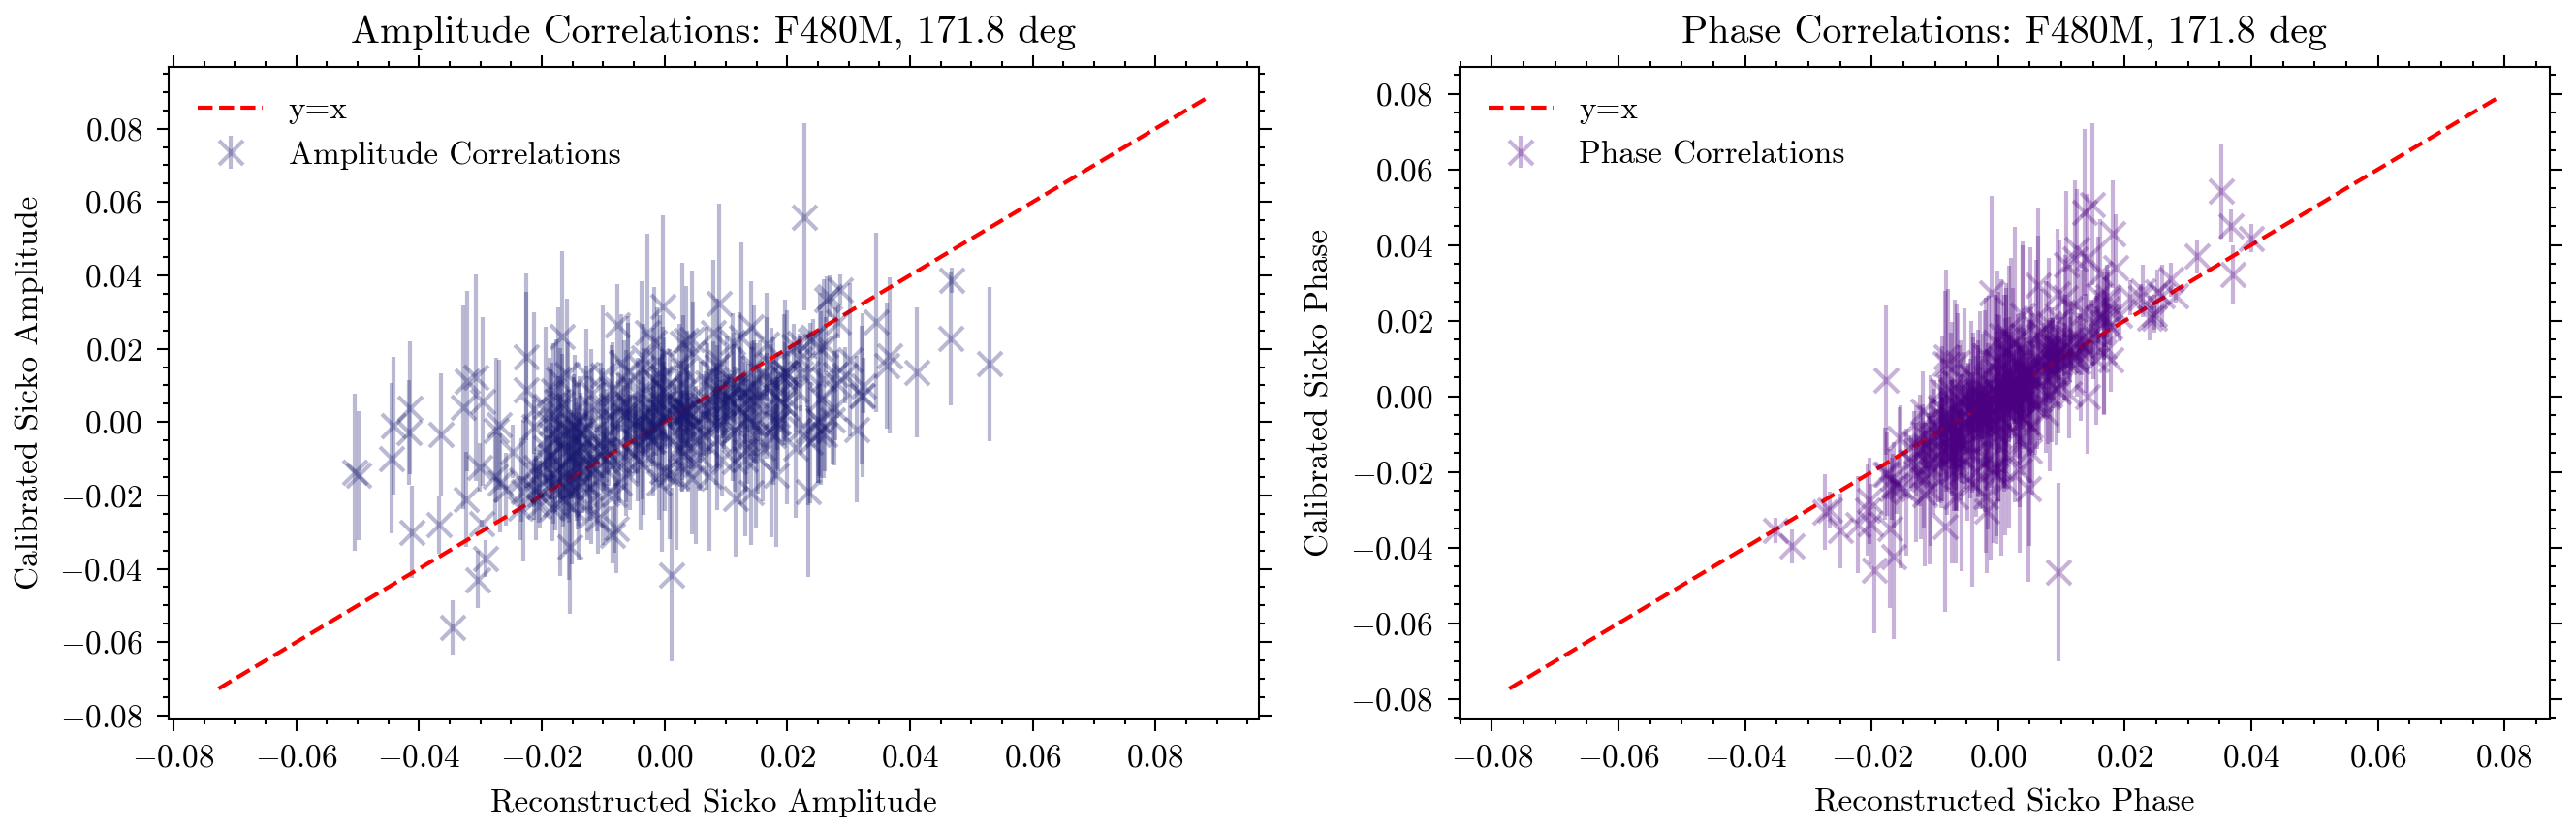

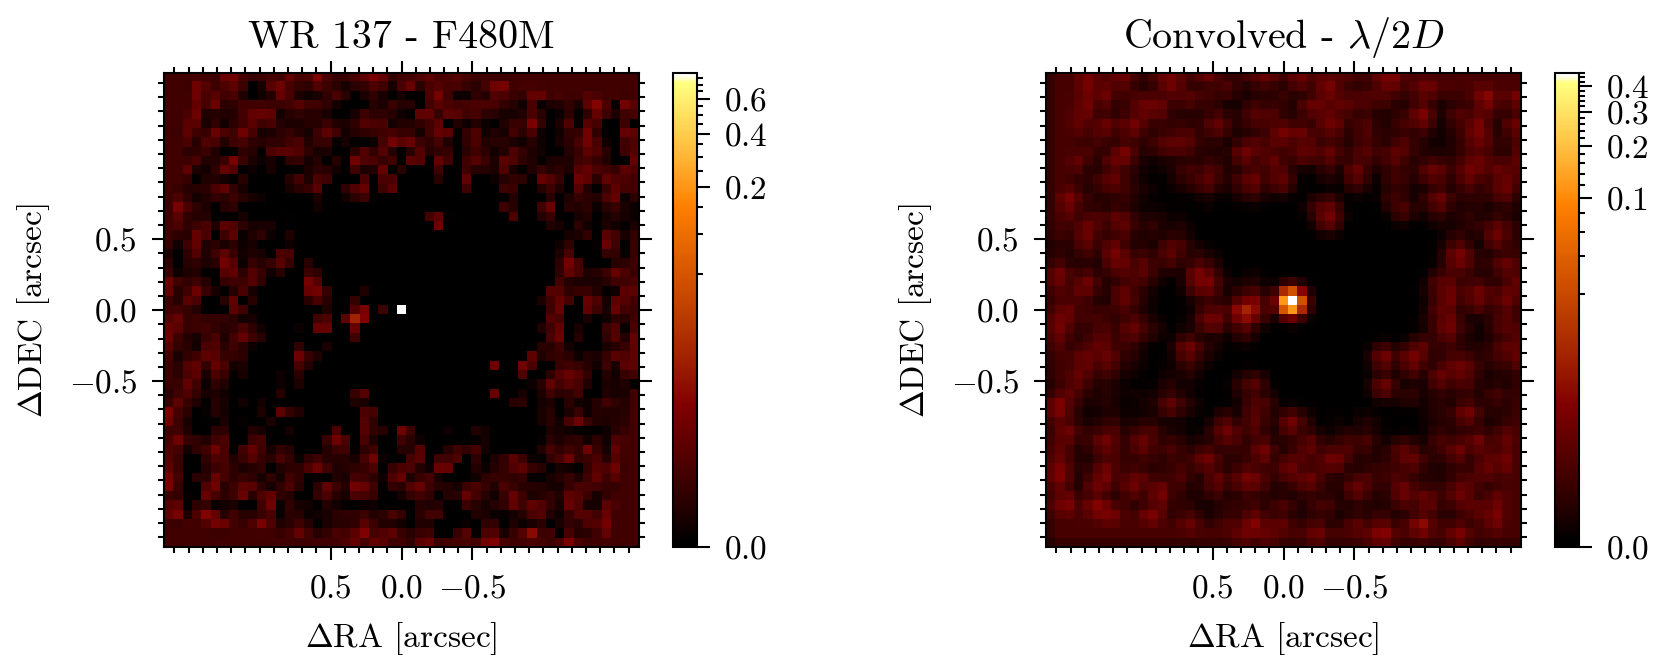

In [37]:
for oi in ois:

    print(bfgs_model.get_distribution(oi).sum())
    print(phase_centre(bfgs_model, oi))
    loss = centered_loss_fn(bfgs_model, oi, args)[0]
    print(f"Loss: {loss:.3e}")

    dist = 10 ** bfgs_model.params["log_dist"][oi.get_key("log_dist")]

    disco_amp, disco_phase = np.split(oi(bfgs_model), 2)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        disco_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.3,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title(f"Amplitude Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        disco_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.3,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title(f"Phase Correlations: {oi.filter}, {oi.parang:.1f} deg")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    ticks = [-0.4, -0.2, 0, 0.2, 0.4]

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

    c0 = dorito.plotting.plot_result(
        ax[0],
        dist,
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.2,
        vmin=0,
    )

    c1 = dorito.plotting.plot_result(
        ax[1],
        blur_distribution(dist, model, oi, factor=0.5),
        pixel_scale=dlu.rad2arcsec(model.pscale_in),
        cmap="afmhot_u",
        power=0.2,
        vmin=None,
    )
    fig.colorbar(c1, ax=ax[1])

    fig.colorbar(c0)
    # pa = model.params["position_angles"][exp.key]

    ax[0].set_title(
        f"WR 137 - {oi.filter}"  # - {model.params['position_angles'][exp.get_key('position_angles')]:.1f}deg"
    )
    ax[1].set(title=r"Convolved - $\lambda / 2D$")

    plt.tight_layout()
    # plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

    # rl_dist = np.clip(dist + 1e-16)
    # rl_dist = rl_dist / rl_dist.max()
    # plt.imshow(rl_dist, norm=mpl.colors.LogNorm(vmin=1e-4, vmax=1.0))
    # plt.colorbar(ticks=[])
    # plt.show()

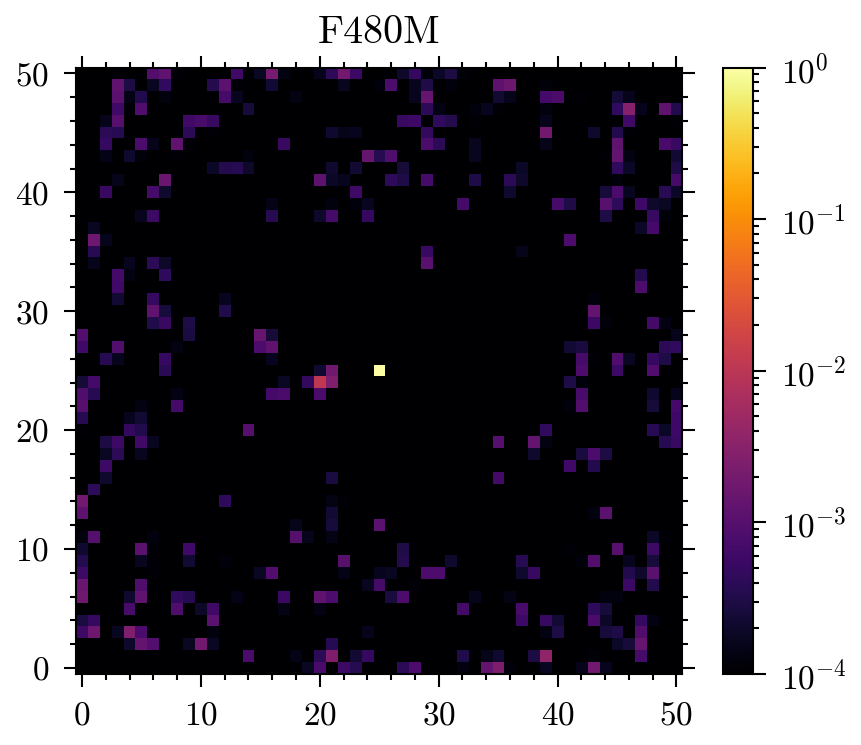

In [36]:
for filt in ["F480M"]:
    dist = 10 ** bfgs_model.params["log_dist"][filt]

    rl_dist = np.clip(dist + 1e-16)
    rl_dist = rl_dist / rl_dist.max()
    plt.imshow(rl_dist, norm=mpl.colors.LogNorm(vmin=1e-4, vmax=1.0))
    plt.title(filt)
    plt.colorbar()
    plt.show()